# Analysis: Risk Profiling
This notebook covers the exploratory data analysis (EDA) of customer risk profiles.
We will analyze the distribution of risk categories and scores, examine correlations 
between risk and other numerical features, and detect high-risk customer outliers.



In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Create connection
conn = sqlite3.connect('../../data/warehouse/enterprise_dw.db')
vis_dir = '../../notebooks/eda/visualizations'
os.makedirs(vis_dir, exist_ok=True)



## Data Loading
We will extract customer risk data, incorporating customer tenure and financial balances 
to build a comprehensive view of risk drivers.



In [2]:
query_risk = """
SELECT 
    r.customer_id,
    r.risk_score,
    r.risk_category,
    r.credit_score,
    c.tenure_days,
    c.tenure_years,
    COALESCE(c_overview.total_balance, 0) as total_balance,
    COALESCE(c_overview.total_accounts, 0) as total_accounts
FROM dim_risk r
JOIN dim_customer c ON r.customer_id = c.customer_id
LEFT JOIN vw_customer_overview c_overview ON r.customer_id = c_overview.customer_id
"""
df_risk = pd.read_sql_query(query_risk, conn)
for col in df_risk.columns:
    if df_risk[col].dtype == 'object':
        try: df_risk[col] = pd.to_numeric(df_risk[col])
        except: pass
df_risk.fillna(0, inplace=True)
df_risk.head()



,customer_id,risk_score,risk_category,credit_score,tenure_days,tenure_years,total_balance,total_accounts
0,CUST00006253,742,Very Low,0.0,2335,6.392882,0,0
1,CUST00009236,623,Medium,0.0,1219,3.337440,0,2
2,CUST00008741,300,High,0.0,1151,3.151266,0,1
3,CUST00002882,600,Medium,0.0,2951,8.079398,0,3
4,CUST00008719,300,High,0.0,2445,6.694045,0,2


## Risk Distribution Profiling
First, we examine how the customer base is distributed across various risk categories.



/var/folders/rr/qkbg923d7ljb97xjb64dbjx40000gn/T/ipykernel_37244/122490519.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_risk, x='risk_category', order=['Low', 'Medium', 'High', 'Critical'], palette='viridis')


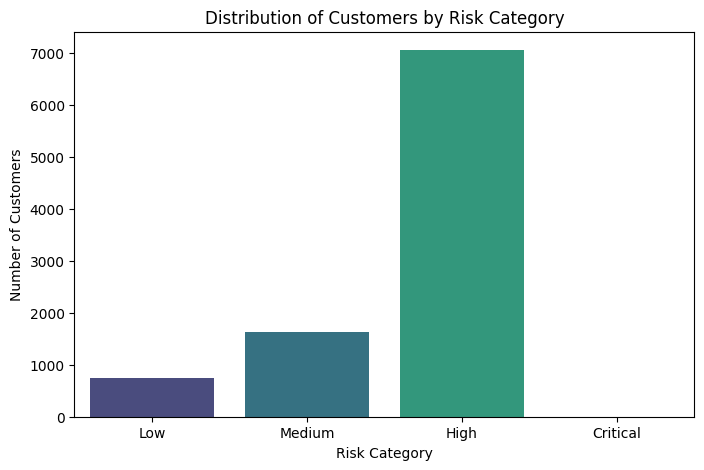

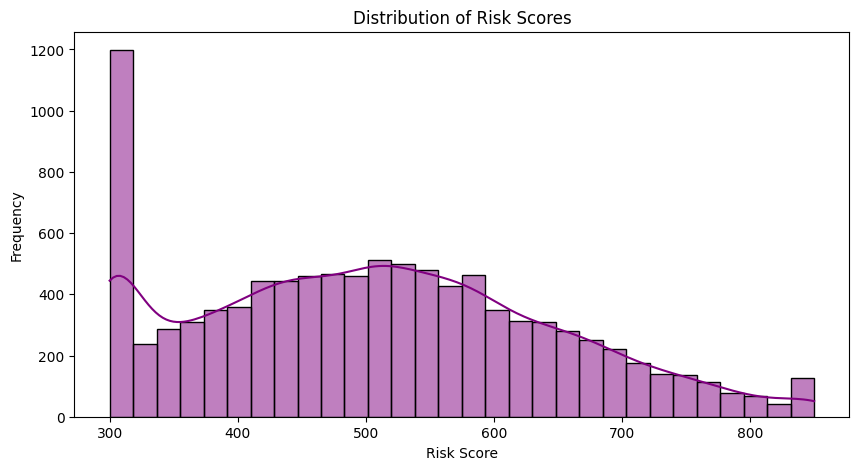

In [3]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df_risk, x='risk_category', order=['Low', 'Medium', 'High', 'Critical'], palette='viridis')
plt.title('Distribution of Customers by Risk Category')
plt.xlabel('Risk Category')
plt.ylabel('Number of Customers')
plt.savefig(f'{vis_dir}/risk_distribution.png', bbox_inches='tight')
plt.show()

plt.figure(figsize=(10, 5))
sns.histplot(data=df_risk, x='risk_score', bins=30, kde=True, color='purple')
plt.title('Distribution of Risk Scores')
plt.xlabel('Risk Score')
plt.ylabel('Frequency')
plt.savefig(f'{vis_dir}/risk_score_histogram.png', bbox_inches='tight')
plt.show()



**Business Interpretation:**
Understanding the concentration of customers in 'High' or 'Critical' risk bands is vital for compliance and capital reserve planning. A right-skewed risk score distribution generally means the majority of the portfolio is healthy, whereas a heavy tail on the higher end signals systemic vulnerability.



## Correlation Matrix & Heatmap
We investigate the linear relationships between the Risk Score and other numerical financial/demographic indicators.



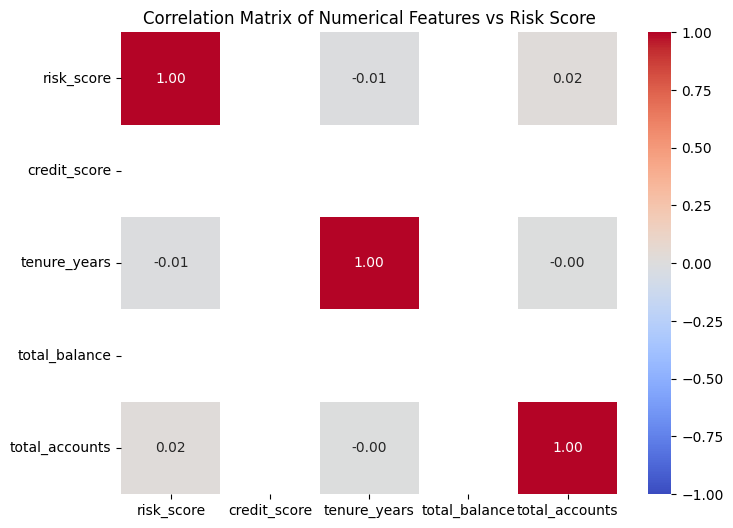

In [4]:
num_cols = ['risk_score', 'credit_score', 'tenure_years', 'total_balance', 'total_accounts']
corr_matrix = df_risk[num_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlation Matrix of Numerical Features vs Risk Score')
plt.savefig(f'{vis_dir}/risk_correlation_heatmap.png', bbox_inches='tight')
plt.show()



**Business Interpretation:**
The heatmap reveals which factors strongly drive risk. For instance, a strong negative correlation between `credit_score` and `risk_score` is expected and validates the scoring model. If `total_balance` or `tenure_years` shows significant correlation, it implies that financial stability and long-term customer relationships effectively mitigate risk.



## Detecting High-Risk Customer Outliers
We can use a boxplot or scatterplot to identify outlier customers who have disproportionately high risk scores compared to their peers.



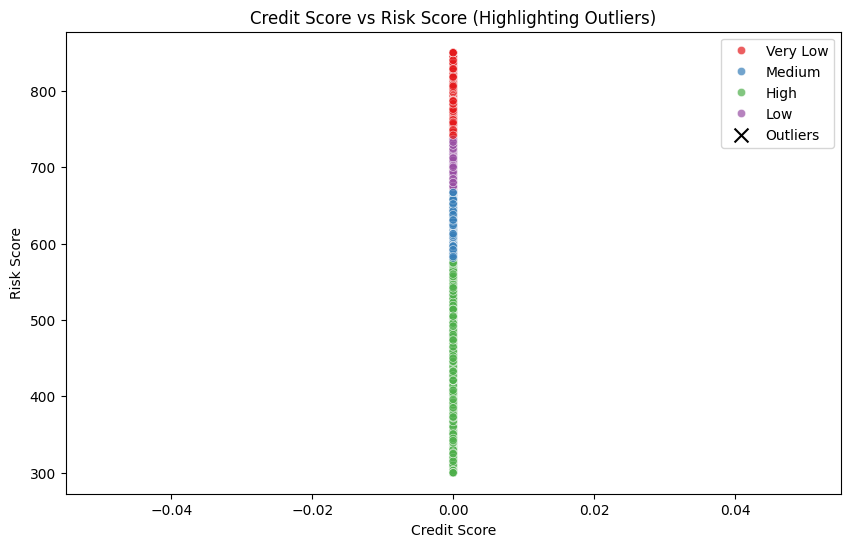

In [5]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_risk, x='credit_score', y='risk_score', hue='risk_category', palette='Set1', alpha=0.7)

# Highlight potential outliers: High Risk Score but unusually high Credit Score (Model divergence)
outliers = df_risk[(df_risk['risk_score'] > df_risk['risk_score'].quantile(0.95)) & 
                   (df_risk['credit_score'] > df_risk['credit_score'].median())]

plt.scatter(outliers['credit_score'], outliers['risk_score'], color='black', marker='x', s=100, label='Outliers')
plt.title('Credit Score vs Risk Score (Highlighting Outliers)')
plt.xlabel('Credit Score')
plt.ylabel('Risk Score')
plt.legend()
plt.savefig(f'{vis_dir}/risk_outliers_scatter.png', bbox_inches='tight')
plt.show()



**Business Interpretation:**
Identifying outliers is crucial for anomaly detection. For example, customers with high credit scores but inexplicably high internal risk scores might be indicative of suspected fraud, recent adverse media, or a flaw in the risk rating algorithm. These cases warrant immediate manual review by the risk management team.
